In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: kaggle


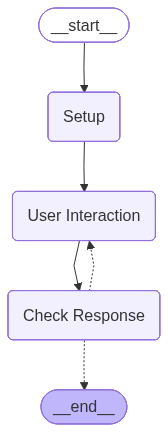

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you tell me the names of players who were inducted into the Hall of Fame and also received awards?


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Find the names of players who were inducted into the Hall of Fame and also received awards.",
    "schema_linking": ["thehistoryofbaseball_hall_of_fame", "thehistoryofbaseball_player", "thehistoryofbaseball_player_award"],
    "answer": "There are 2288 players who were inducted into the Hall of Fame and also received awards. Examples include Old Hoss Radbourn, Tim Keefe, John Clarkson, Amos Rusie, Hugh Duffy, and many others.",
    "sql": "SELECT  p.name_first, p.name_last\nFROM thehistoryofbaseball_hall_of_fame h\nJOIN thehistoryofbaseball_player p ON h.player_id = p.player_id\nJOIN thehistoryofbaseball_player_award pa ON p.player_id = pa.player_id\nWHERE LOWER(h.inducted) = 'y'"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Find the names of players who were inducted into the Hall of Fame and also received awards.",
    "schema_linking": ["thehist

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['NAME_FIRST', 'NAME_LAST'], dtype='object')
Adj. True cols: Index([], dtype='object')
Predicted cols: Index(['NAME_FIRST', 'NAME_LAST'], dtype='object')
Adj. Predicted cols: Index([], dtype='object')
[AI as JUDGE sql query correctness] Result: F with 0.9999996871837232 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 471, 'total_tokens': 473, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'log

...

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects a

[INFO] O resultado da execução foi: {
    "input": "Find the team with the highest average salary.",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_SALARY"],
    "answer": "The team with the highest average salary is LAA, with an average salary of $4,208,636.",
    "sql": "SELECT TEAM_ID, AVG(SALARY) AS AVG_SALARY FROM KAGGLE.THEHISTORYOFBASEBALL_SALARY GROUP BY TEAM_ID ORDER BY AVG_SALARY DESC FETCH FIRST 1 ROWS ONLY"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Find the team with the highest average salary.",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_SALARY"],
    "answer": "The team with the highest average salary is LAA, with an average salary of $4,208,636.",
    "sql": "SELECT TEAM_ID, AVG(SALARY) AS AVG_SALARY FROM KAGGLE.THEHISTORYOFBASEBALL_SALARY GROUP BY TEAM_ID ORDER BY AVG_SALARY DESC FETCH FIRST 1 ROWS ONLY"
}.

[INFO] Avaliando o resultado: {'input': 'Find the team with

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects a

[INFO] O resultado da execução foi: {
    "input": "Find the team with the lowest average salary.",
    "schema_linking": ["kaggle.thehistoryofbaseball_salary"],
    "answer": "The team with the lowest average salary is ML4, with an average salary of $613,243.58.",
    "sql": "SELECT team_id, AVG(salary) AS avg_salary FROM kaggle.thehistoryofbaseball_salary GROUP BY team_id ORDER BY avg_salary ASC FETCH FIRST 1 ROWS ONLY;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Find the team with the lowest average salary.",
    "schema_linking": ["kaggle.thehistoryofbaseball_salary"],
    "answer": "The team with the lowest average salary is ML4, with an average salary of $613,243.58.",
    "sql": "SELECT team_id, AVG(salary) AS avg_salary FROM kaggle.thehistoryofbaseball_salary GROUP BY team_id ORDER BY avg_salary ASC FETCH FIRST 1 ROWS ONLY;"
}.

[INFO] Avaliando o resultado: {'input': 'Find the team with t

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
